In [ ]:
# === Import library ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid")


## Presentation of the variables : 

In the dataset, we can see multiples columns that describe the data that we try to identify : 

| Column      | Description |
|------------|-------------|
| `class_id` | The class ID of the object. For this project, each number reprensent a posture |
| `x_center` | The normalized x-coordinate of the bounding box center. |
| `y_center` | The normalized y-coordinate of the bounding box center. |
| `width`    | The normalized width of the bounding box. |
| `height`   | The normalized height of the bounding box. |


The goal is to annotate humans in landscape and recognize their posture. 

In [ ]:
#  load the dataset
root = Path(r"dataset\labels")
label_files = list(root.rglob("*.txt"))

rows = []
for f in label_files:
    split = f.parent.name  # train / valid / test
    with open(f, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = parts
                rows.append({
                    "split": split,
                    "file": f.stem,
                    "class_id": int(cls),
                    "x_center": float(xc),
                    "y_center": float(yc),
                    "width": float(w),
                    "height": float(h)
                })

df = pd.DataFrame(rows) 

In [11]:
errors = df[
    (df["width"] <= 0) | (df["height"] <= 0) |
    (df["x_center"] < 0) | (df["y_center"] < 0)
]
print("Number of invalid annotations :", len(errors))


Number of invalid annotations : 0


C:\Users\benwa\AppData\Local\Temp\ipykernel_5844\4064548539.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")


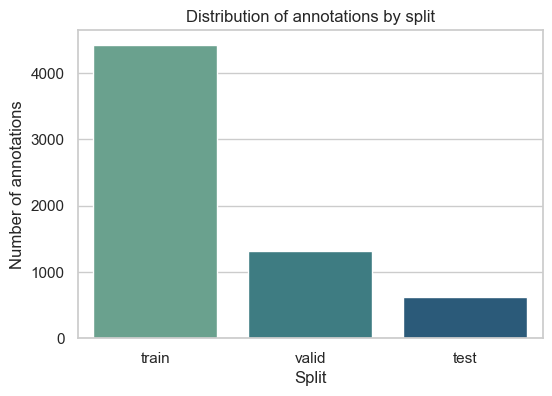

split
train    4424
valid    1312
test      618
Name: count, dtype: int64


In [12]:
split_counts = df["split"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")
plt.title("Distribution of annotations by split")
plt.xlabel("Split")
plt.ylabel("Number of annotations")
plt.show()

print(split_counts)


This analysis examines how the dataset is distributed across the training, validation, and test splits.
Ensuring a balanced split structure is crucial to guarantee that the model learns effectively while still being evaluated on unseen data.
As expected, most annotations are present in the training set, while smaller portions are reserved for validation and testing.
This confirms that the dataset follows a reasonable split ratio suitable for supervised learning.

In [13]:
# === Add names for the class ID
classes = {
    0: "Running",
    1: "Walking",
    2: "Laying_down",
    3: "Not_defined",
    4: "Seated",
    5: "Stands"
}

df["class_name"] = df["class_id"].map(classes)

There is 5 different posture : 
| Column      | Description |
|------------|-------------|
| `0` | The person is running |
| `1` | The person is walking |
| `2` | Laying_down |
| `3`    | Not_defined |
| `4`   | Seated |
| `5`   | Stands |

C:\Users\benwa\AppData\Local\Temp\ipykernel_5844\2476446723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")


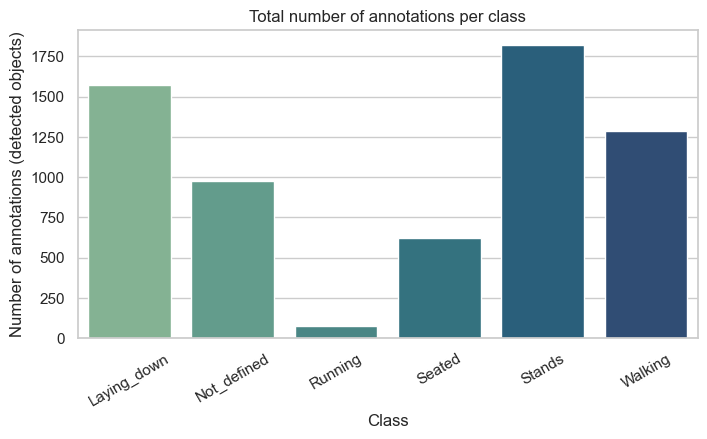

C:\Users\benwa\AppData\Local\Temp\ipykernel_5844\2476446723.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")


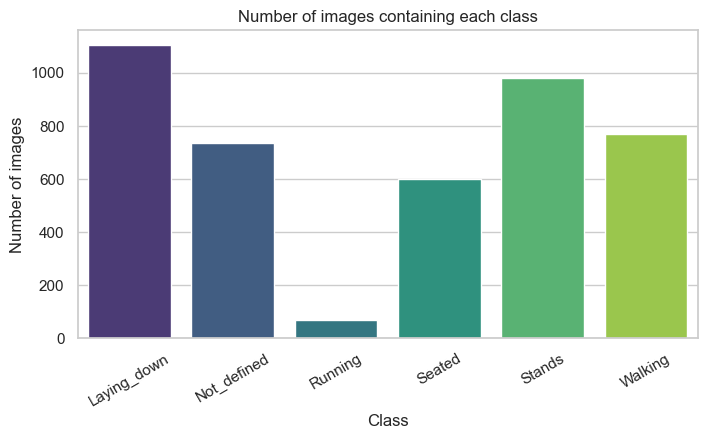

Number of mean object by images: 3.22


In [ ]:
# Analysis of the repartition of Classe ID

# Number of annotation / classes 
annotations_per_class = df["class_name"].value_counts().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=annotations_per_class.index, y=annotations_per_class.values, palette="crest")
plt.title("Total number of annotations per class")
plt.xlabel("Class")
plt.ylabel("Number of annotations (detected objects)")
plt.xticks(rotation=30)
plt.show()

# Number of annotation / images 
images_per_class = df.groupby("class_name")["file"].nunique().sort_index()
plt.figure(figsize=(8,4))
sns.barplot(x=images_per_class.index, y=images_per_class.values, palette="viridis")
plt.title("Number of images containing each class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.show()

objects_per_image = df.groupby("file").size()
print(f"Number of mean object by images: {objects_per_image.mean():.2f}")


This section analyzes the distribution of the six posture classes in the dataset.
The results show a clear class imbalance, with Stands and Laying_down being the most frequent classes, while Running is underrepresented.
Such imbalance can bias the model toward majority classes, resulting in lower detection accuracy for rare postures.
To address this, data augmentation or class weighting strategies may be considered during training.
The average number of annotated objects per image is around 2–3, indicating a moderate annotation density per frame.

In [15]:
# === Descriptive statistics ===
quant_vars = ["x_center", "y_center", "width", "height"]
print("=== Descriptive statistics for quantitative variables ===")
print(df[quant_vars].describe().T)


=== Descriptive statistics for quantitative variables ===
           count      mean       std       min       25%       50%       75%  \
x_center  6354.0  0.501729  0.241245  0.012240  0.305729  0.492969  0.688216   
y_center  6354.0  0.415600  0.240463  0.013889  0.212037  0.392593  0.571759   
width     6354.0  0.024552  0.018547  0.003646  0.012500  0.019271  0.030729   
height    6354.0  0.054299  0.030165  0.009259  0.033333  0.046296  0.065741   

               max  
x_center  0.996615  
y_center  0.988889  
width     0.183854  
height    0.312037  


Descriptive statistics were computed for the four quantitative YOLO variables: x_center, y_center, width, and height.
The mean x_center value (≈0.50) indicates that the objects are symmetrically distributed along the horizontal axis, while the mean y_center (≈0.42) shows a slight tendency toward the lower part of the image.
Bounding box sizes are relatively small (width ≈ 0.024, height ≈ 0.054), which is consistent with detecting individual human postures.
All values fall within the expected [0,1] range, confirming the quality and normalization of the annotations.

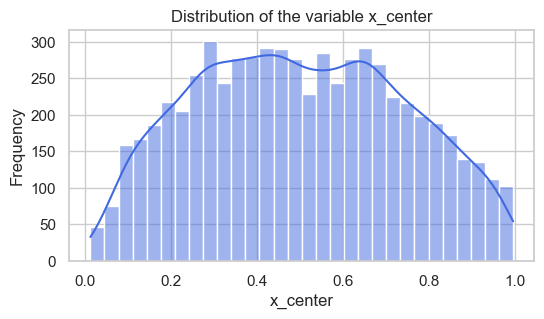

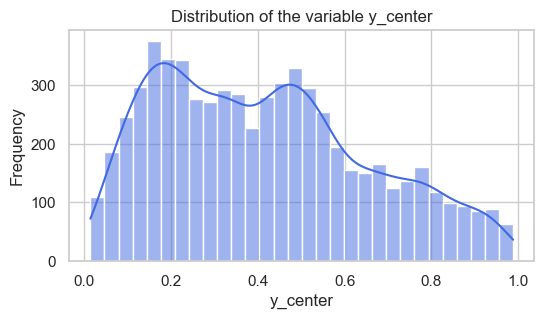

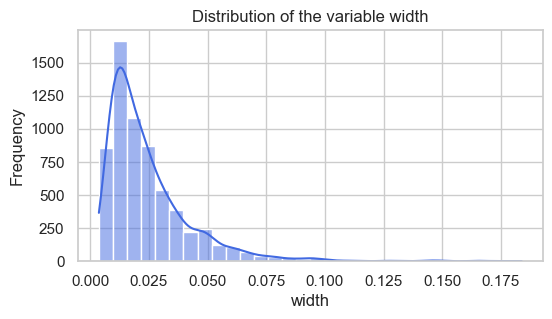

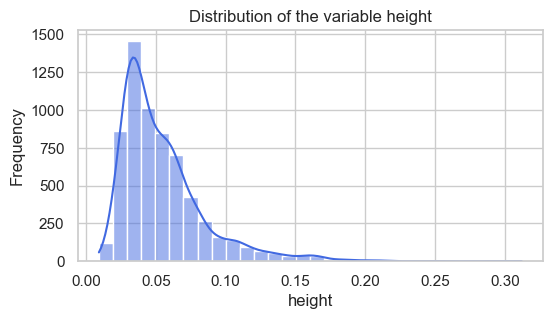

In [16]:
# === Distribution of quantitative variables ===
for var in quant_vars:
    plt.figure(figsize=(6,3))
    sns.histplot(df[var], kde=True, bins=30, color="royalblue")
    plt.title(f"Distribution of the variable {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()


To better understand the spatial and geometric properties of the annotations, we visualized the distributions of the YOLO quantitative variables (x_center, y_center, width, and height).
The x_center values are almost uniformly distributed, indicating that objects appear across the full image width.
The y_center distribution shows a concentration in the lower part of the image, reflecting that most subjects stand on the ground.
Both width and height distributions are right-skewed, confirming that most bounding boxes are small and vertically oriented, which is consistent with detecting human postures.
These findings indicate good annotation consistency and no positional bias.

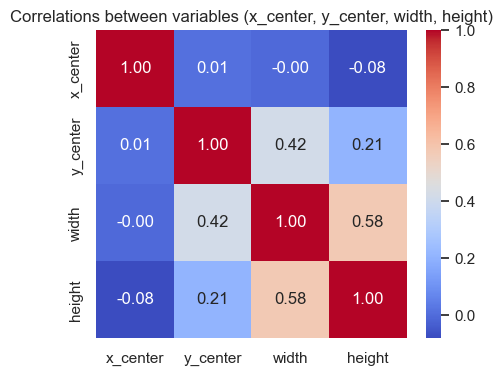

          x_center  y_center     width    height
x_center  1.000000  0.010653 -0.004375 -0.079775
y_center  0.010653  1.000000  0.416885  0.205746
width    -0.004375  0.416885  1.000000  0.575957
height   -0.079775  0.205746  0.575957  1.000000


In [17]:
# ===  Correlations between variables ===
correlations = df[quant_vars].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlations between variables (x_center, y_center, width, height)")
plt.show()

print(correlations)


A correlation heatmap was generated to explore potential relationships between the YOLO annotation variables (x_center, y_center, width, height).
The results show that the bounding box width and height are moderately correlated (r = 0.58), which is expected since larger objects scale in both dimensions.
The slight positive correlations between y_center and size variables suggest that larger objects tend to appear slightly lower in the image, which is consistent with people standing on the ground.
The near-zero correlation between x_center and the other variables confirms that objects are horizontally well distributed.


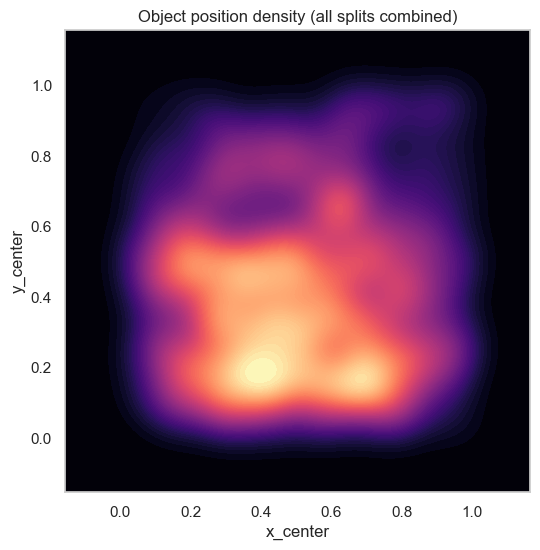

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.kdeplot(
    x=df["x_center"],
    y=df["y_center"],
    fill=True,
    cmap="magma",
    thresh=0,
    levels=100
)
plt.title("Object position density (all splits combined)")
plt.xlabel("x_center")
plt.ylabel("y_center")
plt.show()


A two-dimensional density map was generated using the normalized YOLO coordinates x_center and y_center to visualize the spatial distribution of annotated objects across all dataset splits.

The plot shows a high concentration of annotations in the lower region of the image, indicating that most objects tend to appear near the bottom of the frame. This is expected since the annotated objects (people) are typically standing or positioned on the ground.

The horizontal distribution appears uniform, suggesting that objects are well spread from left to right without positional bias.

Darker areas correspond to regions with few or no annotations — usually the upper part of the image, which often represents the background or sky.

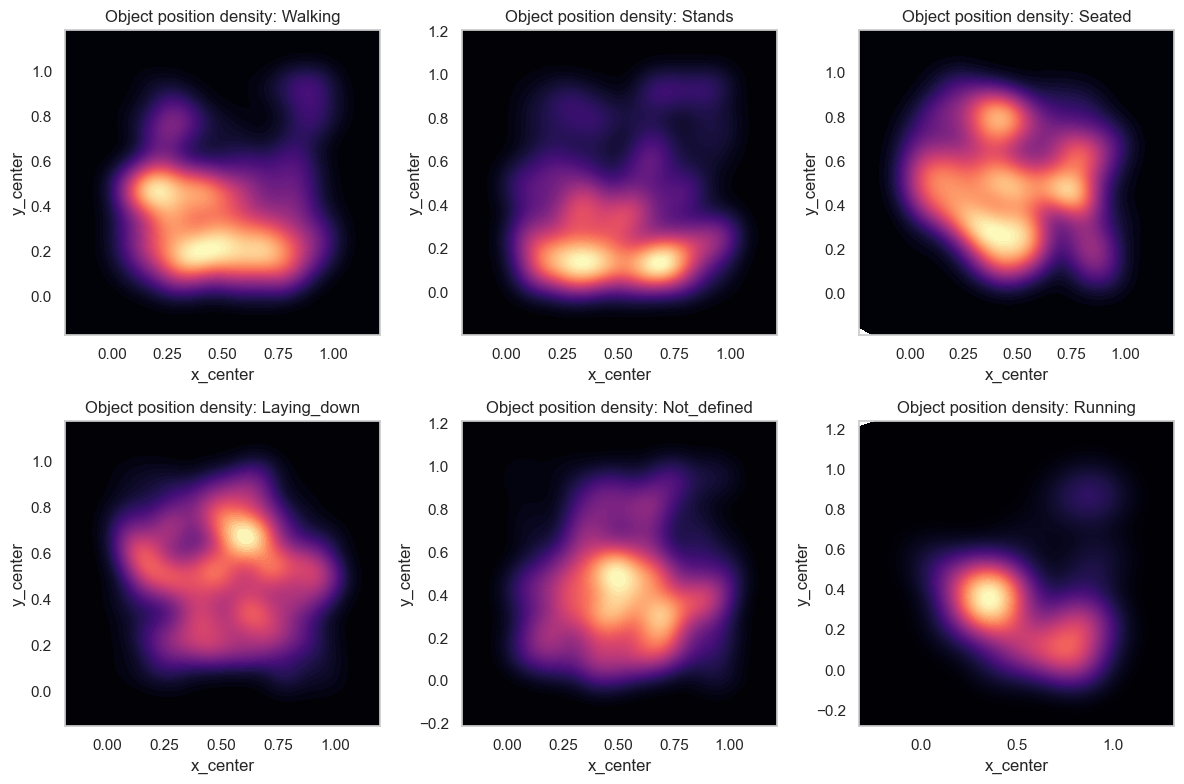

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 2D KDE plots per class ---
plt.figure(figsize=(12, 8))

# List of unique class names
classes = df["class_name"].unique()

# Loop through each class and plot a density map
for i, cls in enumerate(classes, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns for 6 classes
    subset = df[df["class_name"] == cls]
    sns.kdeplot(
        x=subset["x_center"],
        y=subset["y_center"],
        fill=True,
        cmap="magma",
        thresh=0,
        levels=100
    )
    plt.title(f"Object position density: {cls}")
    plt.xlabel("x_center")
    plt.ylabel("y_center")

plt.tight_layout()
plt.show()


This set of density maps illustrates the spatial distribution of object centers (x_center, y_center) for each action class individually.

We can observe distinct spatial patterns depending on the posture:

Standing and Walking objects are mainly concentrated in the lower region of the image, reflecting people in an upright position on the ground.

Laying_down and Seated classes show a more dispersed vertical distribution, often appearing higher in the frame, as their bounding boxes cover less height and may be located further from the ground.

The Running class, although less frequent, follows a similar lower-region pattern to the Standing and Walking classes.

The Not_defined category appears more variable, which is consistent with its nature as a catch-all label.

